# Admixture Simulation in Spatial Transcriptomics

This notebook demonstrates PointillSim's admixture simulation capabilities. Admixture refers to the **misassignment of transcripts to wrong cells**, a common artifact in spatial transcriptomics due to:

1. **Imperfect cell segmentation**: Transcripts near cell boundaries may be assigned to neighboring cells
2. **3D tissue complexity**: Tissue sections (typically 5-10μm) capture signal from cells above/below the imaging plane

Unlike random noise, admixture is **structured** - contaminating transcripts reflect actual cell type expression profiles. This makes it more challenging to identify and correct than random background noise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pointillsim import (
    TissueCellTypes,
    CellTypesProperties,
    HybISS_Setup,
    FOVDistribution,
    FrameWideElement,
    RandomCellTypeRule,
    ProbabilityNodeFieldRule,
    plot_fov,
)
from pointillsim.effects import (
    Lateral2DAdmixture,
    ZAxisAdmixture,
    CompositeAdmixture,
    AdmixtureMetrics,
)

# Set random seed for reproducibility
np.random.seed(42)

## 1. Generate a Simulated FOV

First, let's create a spatially structured tissue with distinct cell type regions.

In [2]:
# Create tissue with gene expression profiles
tissue = TissueCellTypes()
tissue.generate_types_and_markers(
    n_genes=50,
    n_cell_types=5,
    expected_level=15.0,
    concentration=0.85
)

# Create spatially structured FOV using probability field
def create_structured_fov():
    # Define probability nodes for spatial structure
    nodes = np.array([
        [100, 100],  # Cluster 1: Type 0
        [400, 100],  # Cluster 2: Type 1
        [100, 400],  # Cluster 3: Type 2
        [400, 400],  # Cluster 4: Type 3
        [250, 250],  # Center: Type 4
    ])
    
    # Define probabilities at each node
    probs = np.array([
        [0.8, 0.1, 0.05, 0.03, 0.02],  # Node 1: mostly type 0
        [0.1, 0.8, 0.05, 0.03, 0.02],  # Node 2: mostly type 1
        [0.05, 0.1, 0.8, 0.03, 0.02],  # Node 3: mostly type 2
        [0.05, 0.05, 0.1, 0.8, 0.0],   # Node 4: mostly type 3
        [0.2, 0.2, 0.2, 0.2, 0.2],     # Node 5: mixed
    ])
    
    # Create rule with reference_points (FIXED API)
    rule = ProbabilityNodeFieldRule(
        n_cell_types=5,
        n_ref_points=5,
        ref_probs=probs,
        reference_points=nodes,  # FIXED: was node_positions
    )
    
    # Create FOV
    fov_dist = FOVDistribution(
        frame_size=500,
        background_element=lambda: FrameWideElement(
            frame_size=500,
            tipical_cell_spacing=15,
            rules=rule
        )
    )
    
    return fov_dist.generate_fov()

# Generate FOV
np.random.seed(42)
fov = create_structured_fov()

print(f"Generated FOV with {fov.n_cells} cells")
print(f"Cell types: {np.unique(fov.class_instance, return_counts=True)}")

Generated FOV with 1254 cells
Cell types: (array([0, 1, 2, 3, 4]), array([300, 304, 308, 293,  49]))


/mnt/uplamanno/scratch/alireza/PointillSim/pointillsim/utils/interpolation.py:56: UserWarning: `degree` should not be below 1 except -1 when `kernel` is 'thin_plate_spline'.The interpolant may not be uniquely solvable, and the smoothing parameter may have an unintuitive effect.
  self.funcrbf = sp.interpolate.RBFInterpolator(self.points, self.values, degree=0)


In [3]:
# Apply cell properties and observe transcripts
cell_props = CellTypesProperties(
    n_cell_types=5,
    sizes=12,
    size_variation=1.5,
    anisotropy=0.85
)
cell_props.apply(fov)

# Create HybISS setup and observe dots
hybiss = HybISS_Setup(tissue, genes_sensitivities=1.0)
hybiss.observe_dots(fov)
dots_df = hybiss.make_pandas_df()

print(f"Observed {len(dots_df)} transcripts across {fov.n_cells} cells")

Observed 18018 transcripts across 1254 cells


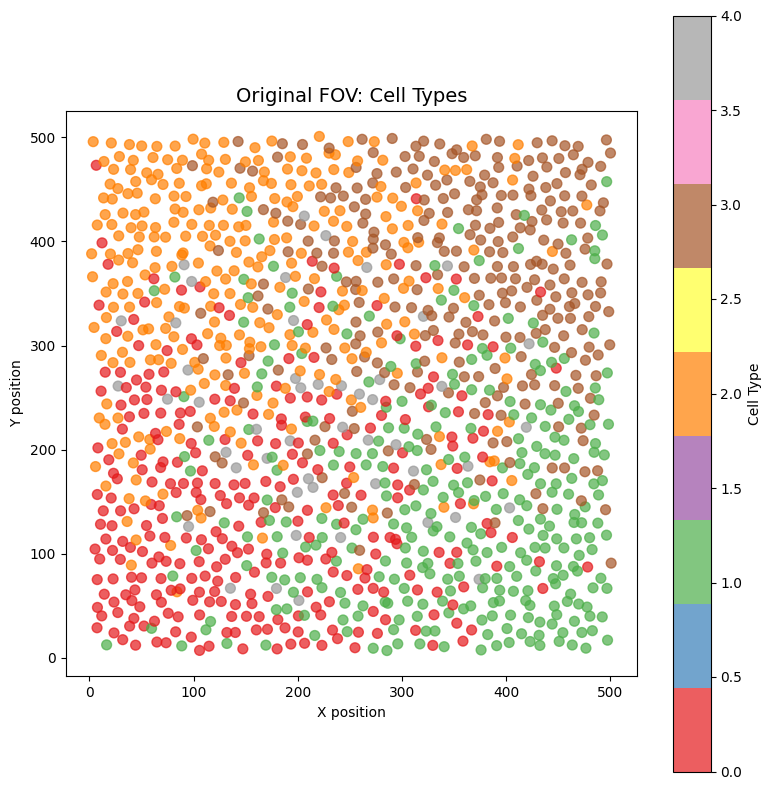

In [4]:
# Visualize the original FOV
fig, ax = plt.subplots(figsize=(8, 8))

# Plot cells colored by type
scatter = ax.scatter(
    fov.cell_centroids[:, 0],
    fov.cell_centroids[:, 1],
    c=fov.class_instance,
    cmap='Set1',
    s=50,
    alpha=0.7
)
plt.colorbar(scatter, label='Cell Type', ax=ax)
ax.set_title('Original FOV: Cell Types', fontsize=14)
ax.set_xlabel('X position')
ax.set_ylabel('Y position')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 2. Lateral 2D Admixture

**Lateral admixture** occurs when transcripts near cell boundaries are misassigned to neighboring cells. This is a common segmentation artifact.

Key parameters:
- `boundary_width`: Width of the zone where misassignment can occur (pixels)
- `transfer_rate`: Probability of transfer at the boundary
- `distance_decay`: How quickly transfer probability decreases toward cell center

In [5]:
# Create lateral admixture model
lateral_admix = Lateral2DAdmixture(
    boundary_width=8.0,     # 8 pixel boundary zone
    transfer_rate=0.4,      # 40% transfer at boundary
    distance_decay=0.3,     # Moderate decay
    seed=42
)

# Get cell data
cell_centroids = fov.cell_centroids
cell_types = fov.class_instance
cell_radii = fov.cell_major_axis / 2

# Apply lateral admixture
dots_lateral = lateral_admix.apply(
    dots_df.copy(),
    cell_centroids,
    cell_types,
    cell_radii
)

# Get summary
summary = lateral_admix.get_admixture_summary()
print("Lateral Admixture Summary:")
print(f"  Total dots: {summary['n_total_dots']}")
print(f"  Reassigned: {summary['n_reassigned']}")
print(f"  Rate: {summary['reassignment_rate']:.2%}")

Lateral Admixture Summary:
  Total dots: 18018
  Reassigned: 3557
  Rate: 19.74%


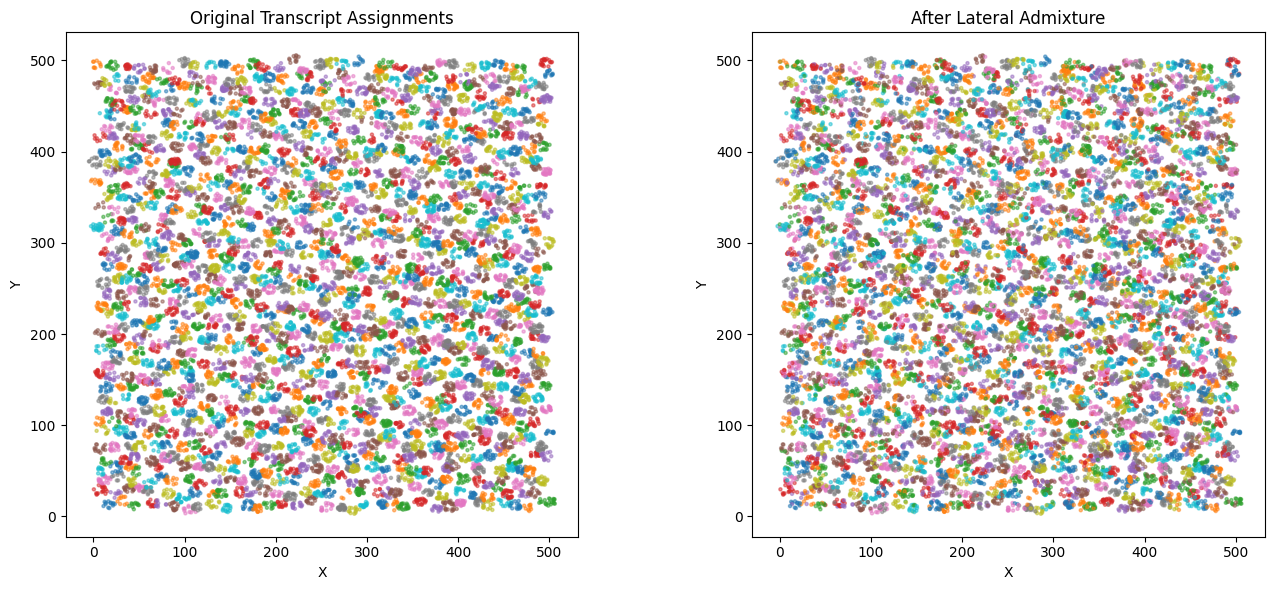

In [6]:
# Visualize lateral admixture events
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original assignments
ax = axes[0]
ax.scatter(
    dots_df['x'], dots_df['y'],
    c=dots_df['cell'] % 10,
    cmap='tab10', s=5, alpha=0.5
)
ax.set_title('Original Transcript Assignments', fontsize=12)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')

# After lateral admixture
ax = axes[1]
ax.scatter(
    dots_lateral['x'], dots_lateral['y'],
    c=dots_lateral['cell'] % 10,
    cmap='tab10', s=5, alpha=0.5
)
ax.set_title('After Lateral Admixture', fontsize=12)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [7]:
# Show admixture events
if lateral_admix.admixture_record is not None and len(lateral_admix.admixture_record) > 0:
    print("Sample admixture events:")
    print(lateral_admix.admixture_record.head(10))
    print(f"\nTotal events: {len(lateral_admix.admixture_record)}")
else:
    print("No admixture events recorded.")

Sample admixture events:
   dot_index  original_cell  new_cell  original_type  new_type      source
0          4              0        34              1         0  lateral_2d
1          8              0         1              1         0  lateral_2d
2         17              1        34              0         0  lateral_2d
3         27              2         1              0         0  lateral_2d
4         28              2         3              0         0  lateral_2d
5         35              3         4              0         0  lateral_2d
6         36              3         4              0         0  lateral_2d
7         38              3         4              0         0  lateral_2d
8         43              3        37              0         1  lateral_2d
9         49              4         3              0         0  lateral_2d

Total events: 3557


## 3. Z-Axis Admixture

**Z-axis admixture** models contamination from cells above/below the imaging plane. In a tissue section (typically 5-10μm thick), transcripts from out-of-plane cells can be detected.

Key insight: Z-neighbors are **NOT random**. Due to 3D tissue continuity, z-neighbor cell types are correlated with the local 2D neighborhood composition.

Parameters:
- `z_contamination_rate`: Fraction of dots from z-neighbors
- `neighborhood_correlation`: How much z-neighbor types follow local 2D composition (0=random, 1=strongly correlated)
- `neighborhood_radius`: Radius for defining local neighborhood

In [ ]:
# Create Z-axis admixture model
z_admix = ZAxisAdmixture(
    z_contamination_rate=0.15,      # 15% of dots from z-neighbors
    neighborhood_correlation=0.8,    # Strong correlation with local composition
    neighborhood_radius=60.0,        # 60 pixel neighborhood
    seed=43
)

# Apply z-axis admixture
dots_z = z_admix.apply(
    dots_df.copy(),
    cell_centroids,
    cell_types,
    cell_radii
)

# Get summary
z_summary = z_admix.get_admixture_summary()
print("Z-Axis Admixture Summary:")
print(f"  Total dots: {z_summary['n_total_dots']}")
print(f"  Reassigned: {z_summary['n_reassigned']}")
print(f"  Rate: {z_summary['reassignment_rate']:.2%}")

Z-Axis Admixture Summary:
  Total dots: 18018
  Reassigned: 2702
  Rate: 15.00%


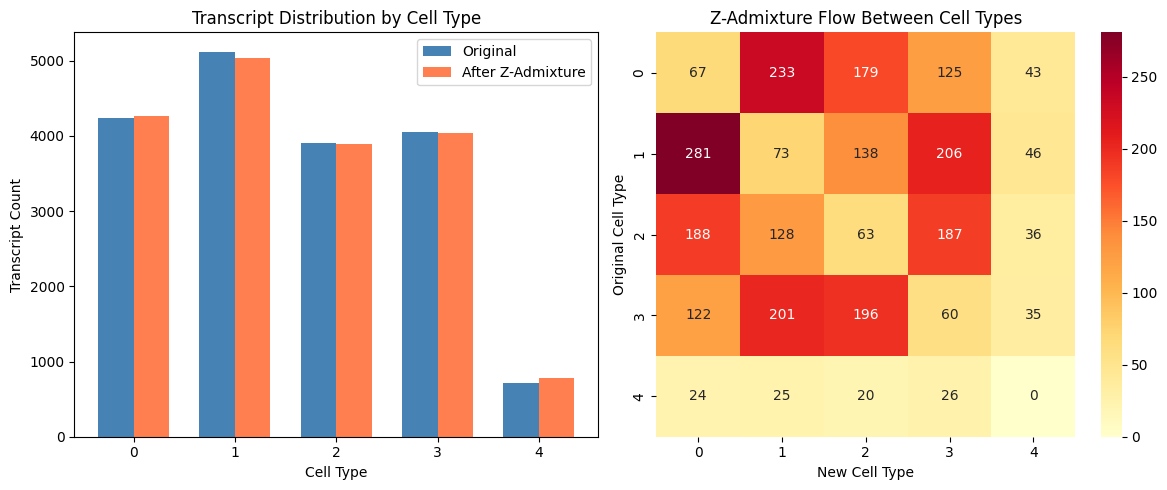

In [9]:
# Compare original and z-admixed type distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count dots per cell type - original
original_counts = []
for i in range(5):
    cells_of_type = np.where(cell_types == i)[0]
    count = dots_df[dots_df['cell'].isin(cells_of_type)].shape[0]
    original_counts.append(count)

# Count dots per cell type - after z-admixture
z_counts = []
for i in range(5):
    cells_of_type = np.where(cell_types == i)[0]
    count = dots_z[dots_z['cell'].isin(cells_of_type)].shape[0]
    z_counts.append(count)

x = np.arange(5)
width = 0.35

ax = axes[0]
ax.bar(x - width/2, original_counts, width, label='Original', color='steelblue')
ax.bar(x + width/2, z_counts, width, label='After Z-Admixture', color='coral')
ax.set_xlabel('Cell Type')
ax.set_ylabel('Transcript Count')
ax.set_title('Transcript Distribution by Cell Type')
ax.set_xticks(x)
ax.legend()

# Show type flow in admixture
ax = axes[1]
if len(z_admix.admixture_record) > 0 and 'original_type' in z_admix.admixture_record.columns:
    flow_data = z_admix.admixture_record.groupby(['original_type', 'new_type']).size().unstack(fill_value=0)
    sns.heatmap(flow_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
    ax.set_title('Z-Admixture Flow Between Cell Types')
    ax.set_xlabel('New Cell Type')
    ax.set_ylabel('Original Cell Type')

plt.tight_layout()
plt.show()

## 4. Combined Admixture

In reality, both lateral and z-axis admixture occur simultaneously. Use `CompositeAdmixture` to combine multiple effects.

In [10]:
# Create combined admixture model
lateral = Lateral2DAdmixture(
    boundary_width=6.0,
    transfer_rate=0.3,
    seed=42
)

z_axis = ZAxisAdmixture(
    z_contamination_rate=0.12,
    neighborhood_correlation=0.75,
    seed=43
)

combined = CompositeAdmixture(models=[lateral, z_axis])

# Apply combined admixture
dots_combined = combined.apply(
    dots_df.copy(),
    cell_centroids,
    cell_types,
    cell_radii
)

print("Combined Admixture Summary:")
combined_summary = combined.get_admixture_summary()
print(f"  Total reassigned: {combined_summary['n_reassigned']}")
print(f"  Overall rate: {combined_summary['reassignment_rate']:.2%}")
print(f"  By source: {combined_summary['by_source']}")

Combined Admixture Summary:
  Total reassigned: 3884
  Overall rate: 21.56%
  By source: {'z_axis': 2162, 'lateral_2d': 1722}


## 5. Admixture Metrics

The `AdmixtureMetrics` class provides detailed analysis of admixture effects.

In [11]:
# Compute admixture metrics
metrics = AdmixtureMetrics(
    admixture_record=combined.admixture_record,
    dots_df=dots_combined,
    cell_types=cell_types,
    cell_centroids=cell_centroids
)

# Overall summary
print("Admixture Metrics Summary:")
summary = metrics.get_summary()
for key, value in summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

Admixture Metrics Summary:
  total_dots_reassigned: 3884
  mean_contamination_per_cell: 0.1767
  max_contamination_per_cell: 0.5714
  cells_with_contamination: 1175
  total_cells: 1254


In [12]:
# Per-cell type statistics
by_type = metrics.get_contamination_by_type()
print("\nContamination by Cell Type:")
display(by_type)


Contamination by Cell Type:


,cell_type,n_cells,mean_contamination,dots_lost,dots_gained,net_flow
0,0,300,0.185686,937,966,29
1,1,304,0.156561,1058,966,-92
2,2,308,0.183248,842,880,38
3,3,293,0.174775,901,868,-33
4,4,49,0.218166,146,204,58


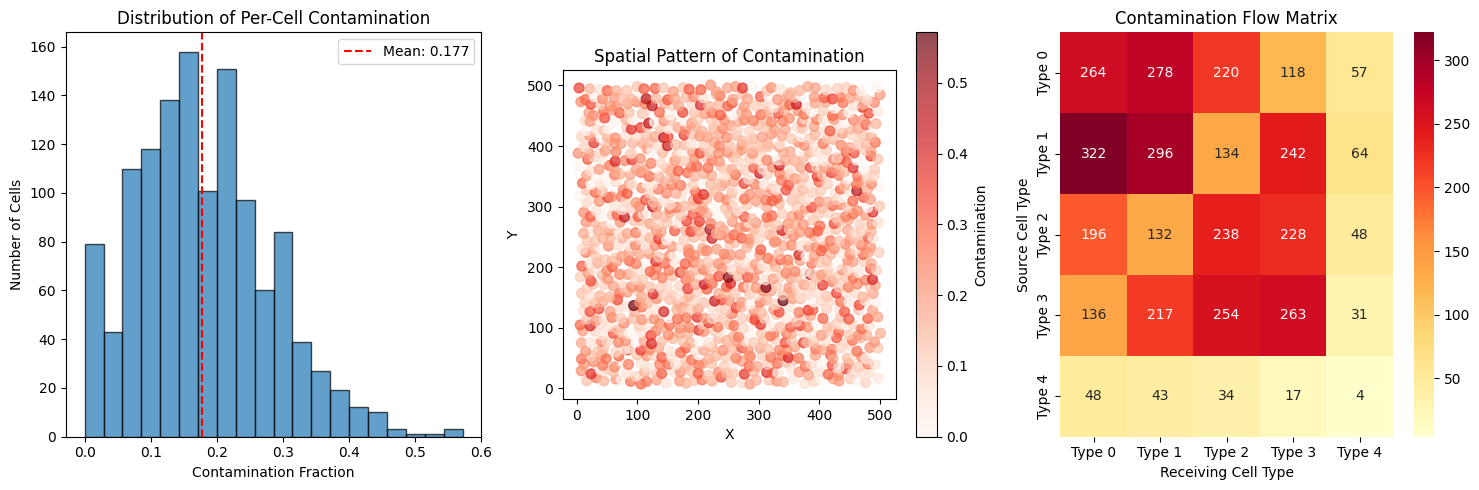

In [13]:
# Visualize per-cell contamination
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Per-cell contamination histogram
ax = axes[0]
ax.hist(metrics.per_cell_contamination, bins=20, edgecolor='black', alpha=0.7)
ax.axvline(metrics.per_cell_contamination.mean(), color='red', linestyle='--', 
           label=f'Mean: {metrics.per_cell_contamination.mean():.3f}')
ax.set_xlabel('Contamination Fraction')
ax.set_ylabel('Number of Cells')
ax.set_title('Distribution of Per-Cell Contamination')
ax.legend()

# Spatial pattern of contamination
ax = axes[1]
scatter = ax.scatter(
    cell_centroids[:, 0],
    cell_centroids[:, 1],
    c=metrics.per_cell_contamination,
    cmap='Reds',
    s=50,
    alpha=0.7
)
plt.colorbar(scatter, ax=ax, label='Contamination')
ax.set_title('Spatial Pattern of Contamination')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')

# Contamination matrix heatmap
ax = axes[2]
sns.heatmap(
    metrics.contamination_matrix,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    ax=ax,
    xticklabels=[f'Type {i}' for i in range(5)],
    yticklabels=[f'Type {i}' for i in range(5)]
)
ax.set_title('Contamination Flow Matrix')
ax.set_xlabel('Receiving Cell Type')
ax.set_ylabel('Source Cell Type')

plt.tight_layout()
plt.show()

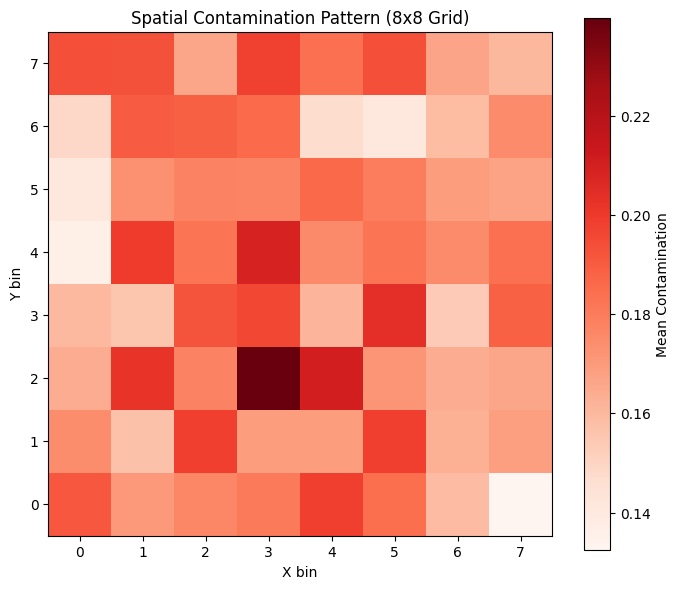

In [14]:
# Spatial contamination pattern (grid-based)
spatial_pattern = metrics.get_spatial_contamination_pattern(grid_size=8)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(spatial_pattern, cmap='Reds', origin='lower', aspect='equal')
plt.colorbar(im, ax=ax, label='Mean Contamination')
ax.set_title('Spatial Contamination Pattern (8x8 Grid)')
ax.set_xlabel('X bin')
ax.set_ylabel('Y bin')
plt.tight_layout()
plt.show()

## 6. Effect of Admixture on Gene Expression

Let's examine how admixture affects the observed gene expression profiles.

In [15]:
def compute_expression_matrix(dots_df, n_cells, gene_names):
    """Compute cell x gene count matrix from dots."""
    n_genes = len(gene_names)
    expr = np.zeros((n_cells, n_genes))
    gene_idx = {g: i for i, g in enumerate(gene_names)}
    
    for _, row in dots_df.iterrows():
        cell = int(row['cell'])
        gene = row['gene']
        if cell < n_cells and gene in gene_idx:
            expr[cell, gene_idx[gene]] += 1
    
    return expr

# Get gene names
gene_names = tissue.gene_names
n_cells = fov.n_cells

# Compute expression matrices
expr_original = compute_expression_matrix(dots_df, n_cells, gene_names)
expr_admixed = compute_expression_matrix(dots_combined, n_cells, gene_names)

print(f"Expression matrices computed:")
print(f"  Original: {expr_original.shape}")
print(f"  Admixed: {expr_admixed.shape}")
print(f"  Mean expression per cell (original): {expr_original.sum(axis=1).mean():.1f}")
print(f"  Mean expression per cell (admixed): {expr_admixed.sum(axis=1).mean():.1f}")

Expression matrices computed:
  Original: (1254, 50)
  Admixed: (1254, 50)
  Mean expression per cell (original): 14.4
  Mean expression per cell (admixed): 14.4


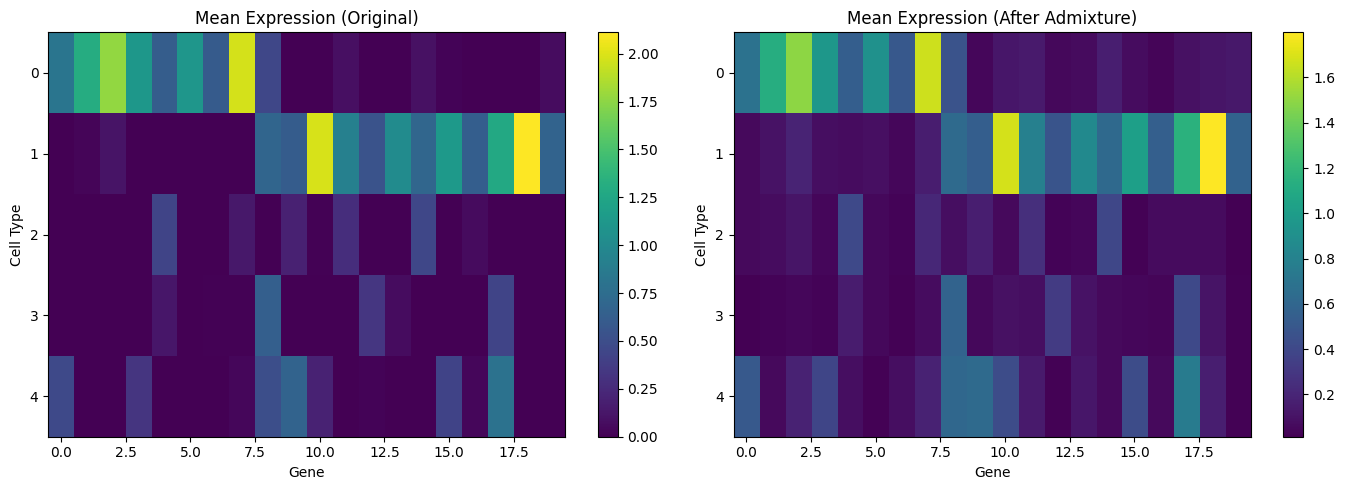

In [16]:
# Compare expression profiles before and after admixture
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean expression per cell type - original
mean_expr_orig = np.zeros((5, len(gene_names)))
mean_expr_admix = np.zeros((5, len(gene_names)))

for ct in range(5):
    cells = np.where(cell_types == ct)[0]
    if len(cells) > 0:
        mean_expr_orig[ct] = expr_original[cells].mean(axis=0)
        mean_expr_admix[ct] = expr_admixed[cells].mean(axis=0)

ax = axes[0]
im = ax.imshow(mean_expr_orig[:, :20], aspect='auto', cmap='viridis')
ax.set_xlabel('Gene')
ax.set_ylabel('Cell Type')
ax.set_title('Mean Expression (Original)')
plt.colorbar(im, ax=ax)

ax = axes[1]
im = ax.imshow(mean_expr_admix[:, :20], aspect='auto', cmap='viridis')
ax.set_xlabel('Gene')
ax.set_ylabel('Cell Type')
ax.set_title('Mean Expression (After Admixture)')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

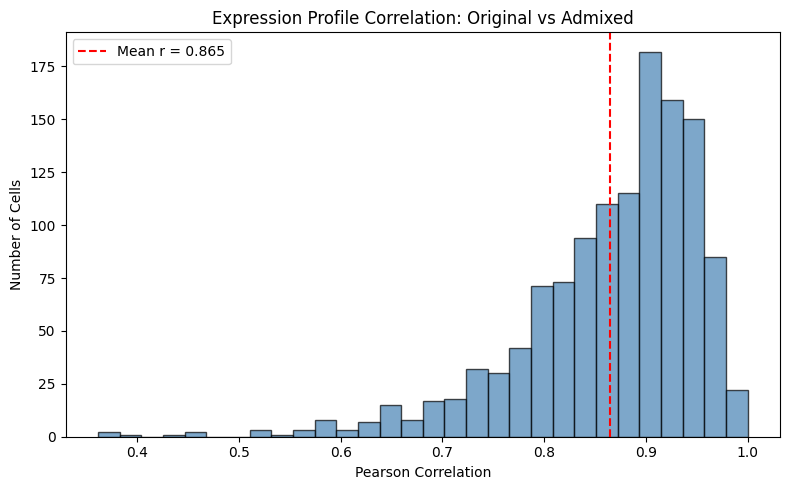

Mean correlation: 0.8651
Cells with r < 0.9: 719 / 1254


In [17]:
# Correlation between original and admixed expression
from scipy.stats import pearsonr

correlations = []
for i in range(n_cells):
    if expr_original[i].sum() > 0 and expr_admixed[i].sum() > 0:
        r, _ = pearsonr(expr_original[i], expr_admixed[i])
        correlations.append(r)

correlations = np.array(correlations)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(correlations, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(correlations.mean(), color='red', linestyle='--',
           label=f'Mean r = {correlations.mean():.3f}')
ax.set_xlabel('Pearson Correlation')
ax.set_ylabel('Number of Cells')
ax.set_title('Expression Profile Correlation: Original vs Admixed')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean correlation: {correlations.mean():.4f}")
print(f"Cells with r < 0.9: {(correlations < 0.9).sum()} / {len(correlations)}")

## 7. Parameter Exploration

Let's explore how different admixture parameters affect the results.

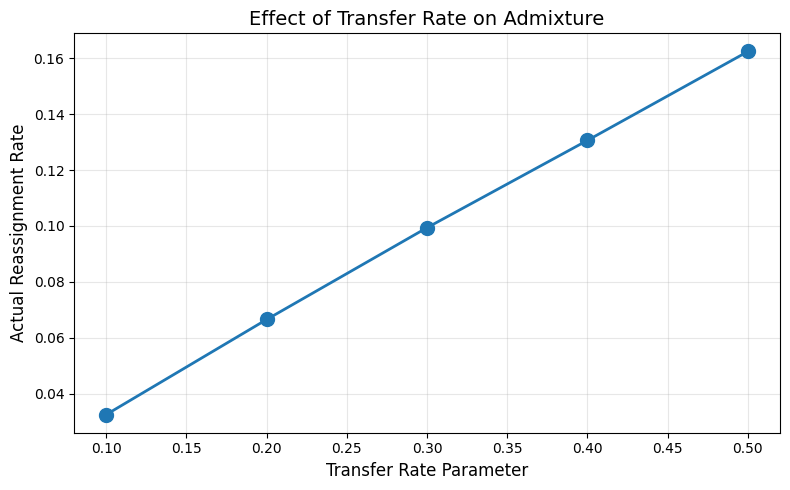

In [18]:
# Explore transfer rate effect
transfer_rates = [0.1, 0.2, 0.3, 0.4, 0.5]
reassignment_rates = []

for rate in transfer_rates:
    admix = Lateral2DAdmixture(
        boundary_width=8.0,
        transfer_rate=rate,
        seed=42
    )
    admix.apply(dots_df.copy(), cell_centroids, cell_types, cell_radii)
    summary = admix.get_admixture_summary()
    reassignment_rates.append(summary['reassignment_rate'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(transfer_rates, reassignment_rates, 'o-', markersize=10, linewidth=2)
ax.set_xlabel('Transfer Rate Parameter', fontsize=12)
ax.set_ylabel('Actual Reassignment Rate', fontsize=12)
ax.set_title('Effect of Transfer Rate on Admixture', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

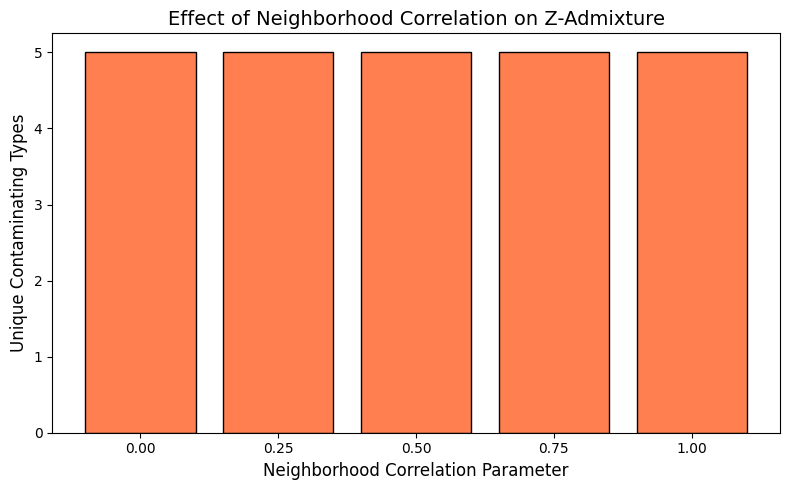

In [19]:
# Explore neighborhood correlation effect (z-axis)
correlations_param = [0.0, 0.25, 0.5, 0.75, 1.0]
type_diversity = []  # Measure diversity of contaminating types

for corr in correlations_param:
    admix = ZAxisAdmixture(
        z_contamination_rate=0.2,
        neighborhood_correlation=corr,
        seed=42
    )
    admix.apply(dots_df.copy(), cell_centroids, cell_types)
    
    if len(admix.admixture_record) > 0 and 'new_type' in admix.admixture_record.columns:
        # Count unique types in admixture
        n_unique = admix.admixture_record['new_type'].nunique()
        type_diversity.append(n_unique)
    else:
        type_diversity.append(0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(len(correlations_param)), type_diversity, color='coral', edgecolor='black')
ax.set_xticks(range(len(correlations_param)))
ax.set_xticklabels([f'{c:.2f}' for c in correlations_param])
ax.set_xlabel('Neighborhood Correlation Parameter', fontsize=12)
ax.set_ylabel('Unique Contaminating Types', fontsize=12)
ax.set_title('Effect of Neighborhood Correlation on Z-Admixture', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:

1. **Lateral2DAdmixture**: Models boundary-based transcript misassignment
   - Affected by `boundary_width`, `transfer_rate`, and `distance_decay`
   - Most relevant for segmentation artifacts

2. **ZAxisAdmixture**: Models out-of-plane cell contamination
   - Controlled by `z_contamination_rate` and `neighborhood_correlation`
   - Contamination is structured, not random

3. **CompositeAdmixture**: Combines multiple admixture effects

4. **AdmixtureMetrics**: Quantifies admixture effects
   - Per-cell contamination rates
   - Contamination flow between cell types
   - Spatial patterns

Admixture simulation is essential for:
- Benchmarking cell type classification methods
- Testing segmentation algorithms
- Evaluating deconvolution approaches
- Understanding real data artifacts